In [15]:
# ===== 1. IMPORTS =====
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import sys

# Make the src/ package importable from within the notebooks/ subfolder.
sys.path.append("..")

# import constants and functions from our src/ modules to keep the notebook clean 
# and focused on the data.
from src.config import (
    SEED, TOP_K_FEATURES, POP_SIZE, N_GENERATIONS,
    MUTATION_RATE, CROSSOVER_RATE, TOURNAMENT_SIZE,
    EARLY_STOP_PATIENCE, MIN_IMPROVEMENT
)
from src.feature_prefilter import prefilter_features 
from src.ga_feature_selection import run_ga

In [16]:
# ===== 2. LOAD PRE-PROCESSED DATA =====
# use split and scaled data from 01_dataset_inspection.ipynb
with open("../data/processed/uci_plf/uci_plf_split_scaled.pkl", "rb") as f:
    X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)

In [17]:
# ===== 3. PREFILTER FEATURES WITH MUTUAL INFORMATION =====
# quick prefiltering step to remove obviously irrelevant features and speed up the GA.
X_train_ga, X_test_ga, selected_prefilter_features, mi_series = prefilter_features(
    X_train_scaled,
    X_test_scaled,
    y_train,
    k=TOP_K_FEATURES,
    seed=SEED
)

print("Features before prefilter:", X_train_scaled.shape[1])
print("Features after prefilter:", X_train_ga.shape[1])

# Show the top-20 features
mi_series.head(20)

Features before prefilter: 48
Features after prefilter: 48


PctExtHyperlinks                      0.459464
PctExtResourceUrls                    0.284287
PctNullSelfRedirectHyperlinks         0.230152
PctExtNullSelfRedirectHyperlinksRT    0.221061
ExtMetaScriptLinkRT                   0.129197
FrequentDomainNameMismatch            0.128943
NumNumericChars                       0.118612
NumDash                               0.115571
SubmitInfoToEmail                     0.081950
NumDots                               0.067908
PathLevel                             0.064036
InsecureForms                         0.057061
QueryLength                           0.053153
PathLength                            0.048728
UrlLength                             0.037332
NumSensitiveWords                     0.032895
NumQueryComponents                    0.032507
HostnameLength                        0.026856
IframeOrFrame                         0.025337
AbnormalExtFormActionR                0.024121
dtype: float64

In [18]:
# ===== 4. RUN THE GENETIC ALGORITHM =====
# run
best_chromosome, best_fitness, selected_features, best_hist, avg_hist = run_ga(
    X_train_ga,
    y_train,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    mutation_rate=MUTATION_RATE,
    crossover_rate=CROSSOVER_RATE,
    tournament_size=TOURNAMENT_SIZE,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_improvement=MIN_IMPROVEMENT,
    seed=SEED
)

print("Best fitness:", best_fitness)
print("Selected feature count:", len(selected_features))
print(selected_features)

Generation   1 | Best: 0.9511 | Avg: 0.9117
Generation   2 | Best: 0.9546 | Avg: 0.9241
Generation   3 | Best: 0.9546 | Avg: 0.9345
Generation   4 | Best: 0.9560 | Avg: 0.9426
Generation   5 | Best: 0.9550 | Avg: 0.9493
Generation   6 | Best: 0.9560 | Avg: 0.9533
Generation   7 | Best: 0.9561 | Avg: 0.9546
Generation   8 | Best: 0.9587 | Avg: 0.9548
Generation   9 | Best: 0.9601 | Avg: 0.9556
Generation  10 | Best: 0.9613 | Avg: 0.9565
Generation  11 | Best: 0.9613 | Avg: 0.9574
Generation  12 | Best: 0.9616 | Avg: 0.9588
Generation  13 | Best: 0.9630 | Avg: 0.9593
Generation  14 | Best: 0.9633 | Avg: 0.9604
Generation  15 | Best: 0.9633 | Avg: 0.9603
Generation  16 | Best: 0.9633 | Avg: 0.9610
Generation  17 | Best: 0.9633 | Avg: 0.9615
Generation  18 | Best: 0.9639 | Avg: 0.9614
Early stopping triggered.
Best fitness: 0.9630005902422344
Selected feature count: 29
['PctExtHyperlinks', 'PctExtResourceUrls', 'PctNullSelfRedirectHyperlinks', 'PctExtNullSelfRedirectHyperlinksRT', 'ExtMeta

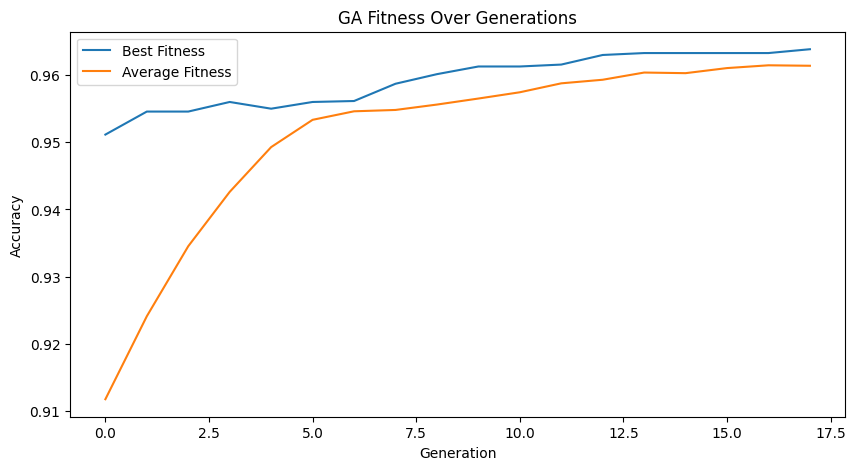

In [19]:
# ===== 5. PLOT GA CONVERGENCE =====
# plot the best and average fitness over generations to visualize convergence.
plt.figure(figsize=(10, 5))
plt.plot(best_hist, label="Best Fitness")
plt.plot(avg_hist, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("GA Fitness Over Generations")
plt.legend()
plt.show()

In [20]:
# ===== 6. SAVE GA RESULTS =====
# Save the selected features and GA history for later use in model evaluation and plotting.
with open("../data/processed/uci_plf/uci_plf_selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

with open("../data/processed/uci_plf/uci_plf_ga_history.pkl", "wb") as f:
    pickle.dump((best_hist, avg_hist), f)